                            OLS Regression Results                            
Dep. Variable:       CorrectedLapTime   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     616.0
Date:                Sat, 04 Jul 2026   Prob (F-statistic):          1.65e-106
Time:                        17:59:20   Log-Likelihood:            -2.2405e+05
No. Observations:               95720   AIC:                         4.482e+05
Df Residuals:                   95682   BIC:                         4.485e+05
Df Model:                          37                                         
Covariance Type:              cluster                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

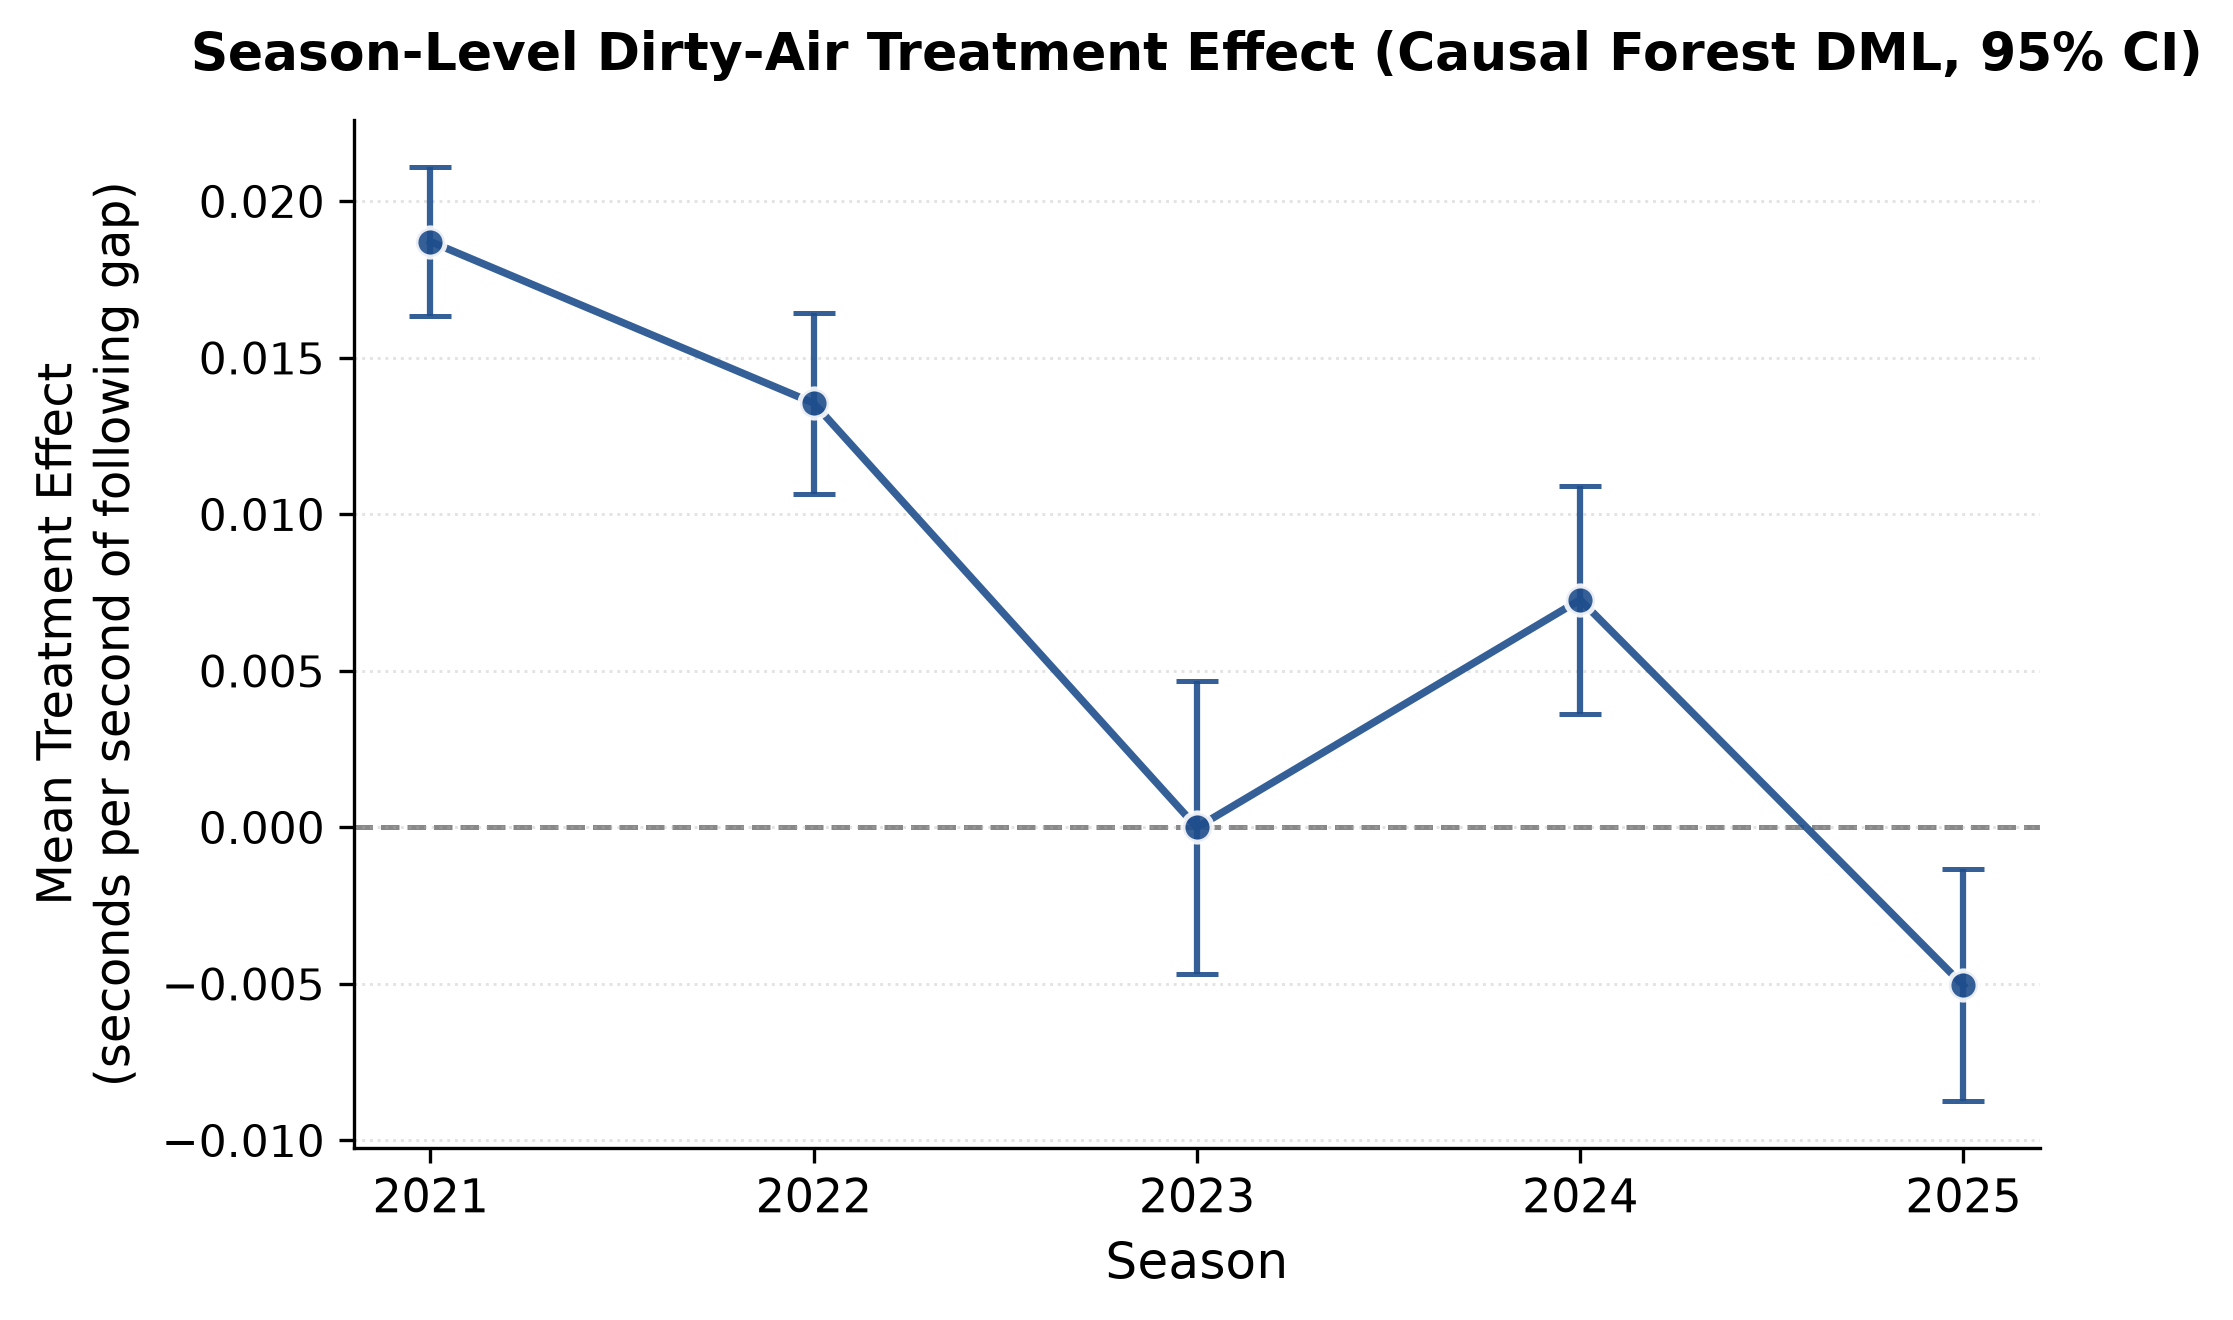

In [5]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib

# Load and filter 
df = pd.read_csv('physics_adjusted_dataset.csv')
df = df.dropna(subset=['CorrectedLapTime', 'GapToCarAhead', 'Compound', 'Circuit', 'Season', 'TyreLife', 'LapNumber'])
df['RaceID'] = df['Season'].astype(str) + '_' + df['Circuit']

circuit_season_counts = df.groupby('Circuit')['Season'].nunique()
valid_circuits = circuit_season_counts[circuit_season_counts >= 2].index
df = df[df['Circuit'].isin(valid_circuits)]

# OLS: season-interaction
formula = (
    'CorrectedLapTime ~ GapToCarAhead * C(Season, Treatment(reference=2021)) '
    '+ C(Circuit) + C(Compound) + TyreLife + LapNumber'
)
ols_model = smf.ols(formula, data=df).fit()
ols_robust = ols_model.get_robustcov_results(cov_type='cluster', groups=df['RaceID'])
print(ols_robust.summary())

# Causal Forest DML: Season as heterogeneity variable 
le_circuit = LabelEncoder()
le_compound = LabelEncoder()
df['Circuit_enc'] = le_circuit.fit_transform(df['Circuit'])
df['Compound_enc'] = le_compound.fit_transform(df['Compound'])

T = df['GapToCarAhead'].values
Y = df['CorrectedLapTime'].values
X = df[['Season']].values
W = df[['Circuit_enc', 'Compound_enc', 'TyreLife', 'LapNumber']].values

cf_model = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, n_jobs=-1),
    model_t=RandomForestRegressor(n_estimators=100, n_jobs=-1),
    n_estimators=200,
    random_state=42
)
cf_model.fit(Y, T, X=X, W=W)

# Per-season mean effect + 95% CI via econml's built-in effect_interval() 
seasons = sorted(df['Season'].unique())
X_seasons = np.array([[s] for s in seasons])

means = cf_model.effect(X_seasons)
lower, upper = cf_model.effect_interval(X_seasons, alpha=0.05)

for s, m, l, u in zip(seasons, means, lower, upper):
    print(f"{s}: mean={m:.6f}, CI=[{l:.6f}, {u:.6f}], width={u-l:.6f}")

# Plot 
err_lower = [m - l for m, l in zip(means, lower)]
err_upper = [u - m for u, m in zip(upper, means)]

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)
ax.errorbar(
    seasons, means, yerr=[err_lower, err_upper],
    marker='o', markersize=7, markerfacecolor='#1f4e8c', markeredgecolor='white',
    markeredgewidth=1.2, linewidth=1.8, color='#1f4e8c',
    capsize=5, capthick=1.5, elinewidth=1.5, ecolor='#1f4e8c', alpha=0.9
)
ax.axhline(0, color='#888888', linestyle='--', linewidth=1.2, zorder=0)
ax.set_xlabel('Season', fontsize=12, fontweight='medium')
ax.set_ylabel('Mean Treatment Effect\n(seconds per second of following gap)', fontsize=11.5)
ax.set_title('Season-Level Dirty-Air Treatment Effect (Causal Forest DML, 95% CI)', fontsize=12.5, fontweight='bold', pad=12)
ax.set_xticks(seasons)
ax.set_xticklabels([str(s) for s in seasons], fontsize=11)
ax.tick_params(axis='y', labelsize=10.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.35, linewidth=0.7)

plt.tight_layout()
plt.savefig('phase8_5_season_treatment_effect.pdf', bbox_inches='tight')
plt.savefig('phase8_5_season_treatment_effect.png', bbox_inches='tight', dpi=300)
plt.show()